In [1]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn import tree
import matplotlib.pyplot as plt

In [2]:
# 1. Load Data
df = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\MUMBAI UNIVERSITY\\SEM 2\\PRODIGY_DS_03\\bank.csv")

# 2. Convert categorical variables into dummy/indicator variables (One-Hot Encoding)
# This turns columns like 'job' into multiple columns with 0s and 1s
df_final = pd.get_dummies(df, drop_first=True)

# 3. Define X (Features) and y (Target)
# Assuming 'deposit' or 'y' is the target column (Yes/No if they bought the product)
X = df_final.drop('deposit_yes', axis=1) # Adjust column name based on your CSV
y = df_final['deposit_yes']

# 4. Split data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# 1. Initialize the Classifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# 2. Train the model
clf.fit(X_train, y_train)

# 3. Make predictions
y_pred = clf.predict(X_test)

# 4. Check Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.77
              precision    recall  f1-score   support

       False       0.85      0.68      0.76      1166
        True       0.71      0.87      0.78      1067

    accuracy                           0.77      2233
   macro avg       0.78      0.77      0.77      2233
weighted avg       0.78      0.77      0.77      2233



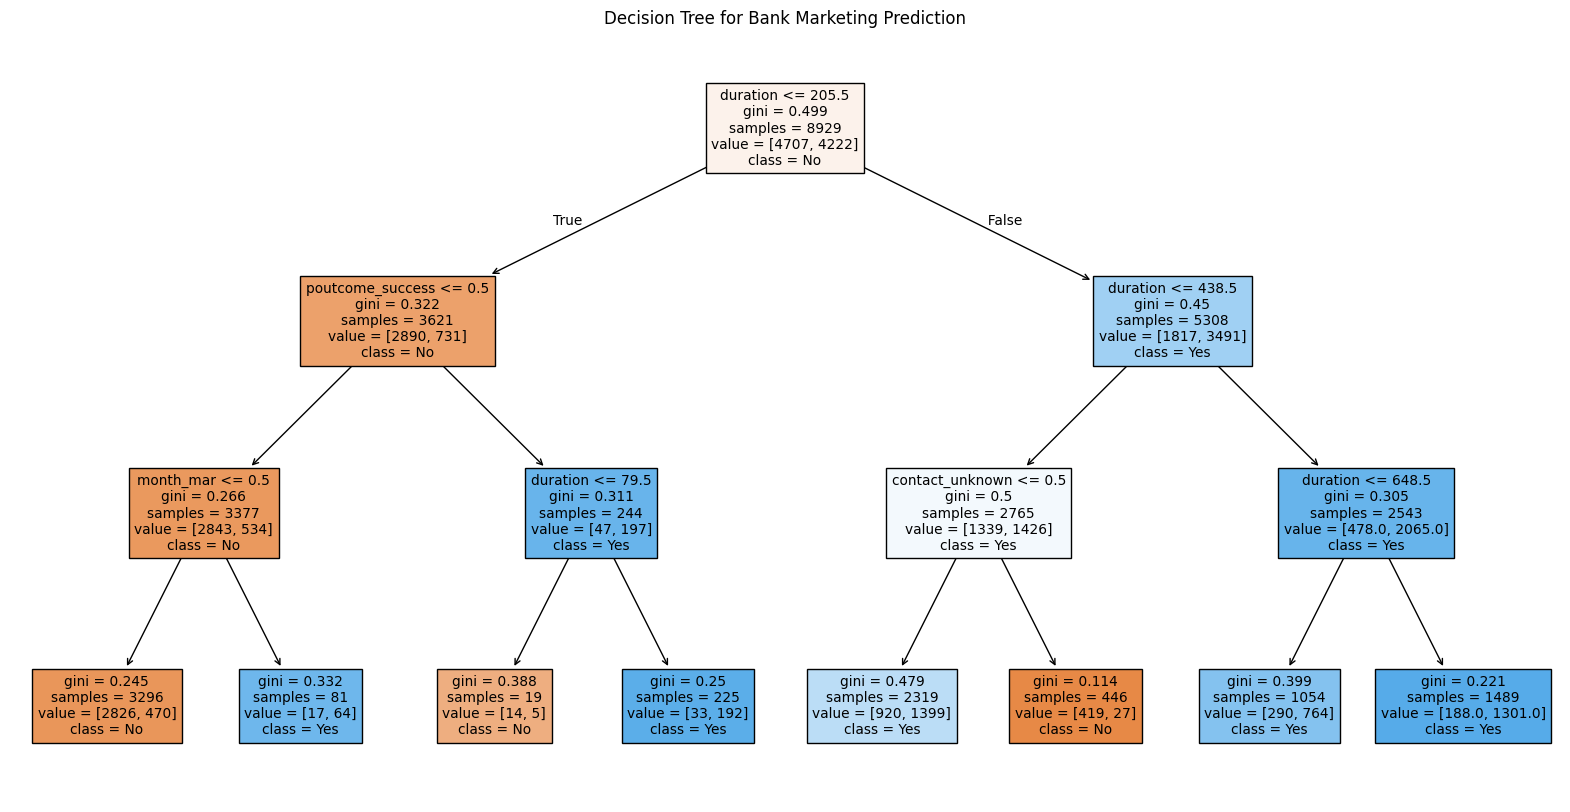

In [4]:
plt.figure(figsize=(20,10))
tree.plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.title("Decision Tree for Bank Marketing Prediction")
plt.savefig('decision_tree.png') # Save this for GitHub!
plt.show()